In [15]:
import os
import pandas as pd
import numpy as np
import re
import utils

In [16]:
# Make output folder
output_dir = os.path.join('..','..','..','plots','modelling')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [17]:
preprocessed_model_fit_folder = f'/Volumes/project/3025011.02/pre-processed/modelling/model_fit'
model_fit_pattern = re.compile(r'^model_fit_sub-\d{3}_session-\d{2}\.csv$')

## Which subjects and sessions do we want to include?

In [18]:
unique_subject_ids = [5, 10, 13, 14, 15, 16, 20, 22, 23, 25, 27, 28, 29, 30, 32, 37] #[5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37]
unique_sessions = [1, 2, 3, 4]

In [19]:
model_fit_combined = []
# Iterate through files in the folder
for file_name in os.listdir(preprocessed_model_fit_folder):
    if model_fit_pattern.match(file_name):
        path = os.path.join(preprocessed_model_fit_folder, file_name)
        model_fit = pd.read_csv(path, sep=';')
        model_fit_combined.append(model_fit)

model_fit_combined = pd.concat(model_fit_combined, ignore_index=True)
model_fit_combined = model_fit_combined.sort_values(by=['subject', 'session'])
print(model_fit_combined)

    subject  session  trials   model0_ll  model0_q_happy_pull  \
5         5        1     646 -433.348327            -0.406640   
18        5        2     656 -453.861715            -0.374557   
38        5        3     655 -451.260352            -0.669704   
22        5        4     660 -453.183480            -0.409090   
3        10        1     658 -454.762216             0.039031   
2        10        2     655 -451.443903            -0.431997   
9        10        3     658 -456.060504            -0.502508   
14       10        4     654 -453.131677            -0.732974   
1        13        1     629 -432.921191            -0.112313   
0        13        2     378 -260.599975             0.740575   
6        14        1     648 -447.990521             0.196852   
12       14        2     658 -455.494915             0.301354   
11       14        3     656 -451.129295            -0.583203   
13       14        4     655 -453.948784            -0.153424   
7        15        1     

In [20]:
## Only keep the rows with subjects and sessions we want
model_fit_combined = model_fit_combined[
    model_fit_combined['subject'].isin(unique_subject_ids) &
    model_fit_combined['session'].isin(unique_sessions)
]

In [21]:
# Automatically detect models
models = [col.split('_')[0] for col in model_fit_combined.columns if '_ll' in col]
models = sorted(set(models))

In [22]:
# Initialize dictionaries for AIC/BIC
for model in models:
    # Count the number of parameters per model
    param_cols = [col for col in model_fit_combined.columns if col.startswith(model + '_') and col != model + '_ll']
    k = len(param_cols)

    # Get negative log-likelihoods
    ll = model_fit_combined[f'{model}_ll']
    #ll = -neg_ll  # Convert to positive log-likelihood

    # Calculate AIC and BIC
    model_fit_combined[f'{model}_AIC'] = 2 * k - 2 * ll
    model_fit_combined[f'{model}_BIC'] = k * np.log(model_fit_combined['trials']) - 2 * ll

print(model_fit_combined)

    subject  session  trials   model0_ll  model0_q_happy_pull  \
5         5        1     646 -433.348327            -0.406640   
18        5        2     656 -453.861715            -0.374557   
38        5        3     655 -451.260352            -0.669704   
22        5        4     660 -453.183480            -0.409090   
3        10        1     658 -454.762216             0.039031   
2        10        2     655 -451.443903            -0.431997   
9        10        3     658 -456.060504            -0.502508   
14       10        4     654 -453.131677            -0.732974   
1        13        1     629 -432.921191            -0.112313   
0        13        2     378 -260.599975             0.740575   
6        14        1     648 -447.990521             0.196852   
12       14        2     658 -455.494915             0.301354   
11       14        3     656 -451.129295            -0.583203   
13       14        4     655 -453.948784            -0.153424   
7        15        1     

In [23]:
# Fixed effects group comparison for AIC and BIC
# Take columns that contain AIC or BIC
aic_bic_cols = [col for col in model_fit_combined.columns if 'AIC' in col or 'll' in col]

# Build the total row as a dict comprehension
total_row = {
    col: model_fit_combined[col].sum()   if col in aic_bic_cols
         else 0
    for col in model_fit_combined.columns
}

# Overwrite the session/subject entries
total_row['subject'] = 'total'
total_row['session'] = 'total'

# Add the total row to the DataFrame
total_df = pd.DataFrame([total_row])
model_fit_combined = pd.concat([model_fit_combined, total_df], ignore_index=True)
print(model_fit_combined)

   subject session  trials     model0_ll  model0_q_happy_pull  \
0        5       1     646   -433.348327            -0.406640   
1        5       2     656   -453.861715            -0.374557   
2        5       3     655   -451.260352            -0.669704   
3        5       4     660   -453.183480            -0.409090   
4       10       1     658   -454.762216             0.039031   
5       10       2     655   -451.443903            -0.431997   
6       10       3     658   -456.060504            -0.502508   
7       10       4     654   -453.131677            -0.732974   
8       13       1     629   -432.921191            -0.112313   
9       13       2     378   -260.599975             0.740575   
10      14       1     648   -447.990521             0.196852   
11      14       2     658   -455.494915             0.301354   
12      14       3     656   -451.129295            -0.583203   
13      14       4     655   -453.948784            -0.153424   
14      15       1     65

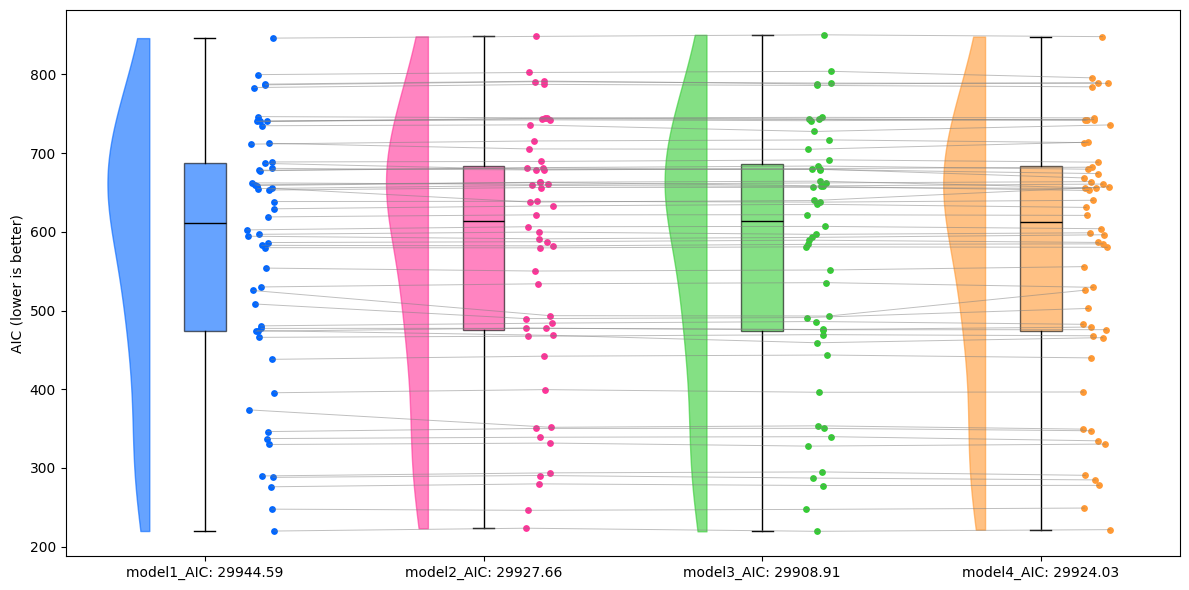

In [24]:
# Remove total column
model_fit_plot = model_fit_combined[model_fit_combined['subject'] != 'total']
model_fit_total = model_fit_combined[model_fit_combined['subject'] == 'total']

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    model_fit_plot,
    columns=['model1_AIC', 'model2_AIC', 'model3_AIC', 'model4_AIC'],
    labels=[f'model1_AIC: {model_fit_total["model1_AIC"].iloc[0]:.2f}', f'model2_AIC: {model_fit_total["model2_AIC"].iloc[0]:.2f}', f'model3_AIC: {model_fit_total["model3_AIC"].iloc[0]:.2f}', f'model4_AIC: {model_fit_total["model4_AIC"].iloc[0]:.2f}'],
    output_dir=output_dir,
    ylabel_name='AIC (lower is better)',
    plot_name='model_comparison_AIC'
)

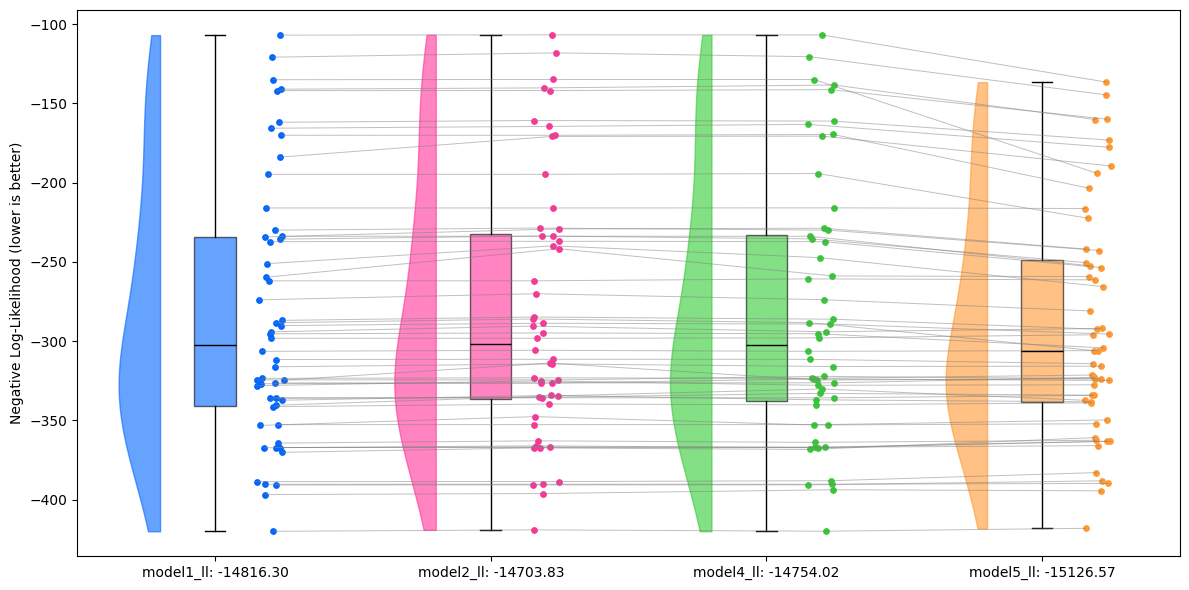

In [25]:
# Remove total column
model_fit_plot = model_fit_combined[model_fit_combined['subject'] != 'total']
model_fit_total = model_fit_combined[model_fit_combined['subject'] == 'total']

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    model_fit_plot,
    columns=['model1_ll', 'model2_ll', 'model5_ll','model6_ll'],
    labels=[f'model1_ll: {model_fit_total["model1_ll"].iloc[0]:.2f}', f'model2_ll: {model_fit_total["model2_ll"].iloc[0]:.2f}', f'model5_ll: {model_fit_total["model5_ll"].iloc[0]:.2f}', f'model6_ll: {model_fit_total["model6_ll"].iloc[0]:.2f}'],
    output_dir=output_dir,
    ylabel_name='Negative Log-Likelihood (lower is better)',
    plot_name='model_comparison_negative_log_likelihood'
)

In [26]:
# Print and save
print(model_fit_combined[['subject'] + [col for col in model_fit_combined.columns if 'AIC' in col or 'BIC' in col]])
model_fit_combined.to_csv(f'{preprocessed_model_fit_folder}/model_fit_comparison.csv', index=False, sep=';')

   subject    model0_AIC  model0_BIC    model1_AIC  model1_BIC    model2_AIC  \
0        5    878.696654  905.521451    474.504698  487.917097    468.421886   
1        5    919.723430  946.640395    579.838668  593.297150    579.578748   
2        5    914.520703  941.428515    473.691996  487.145902    477.650243   
3        5    918.366959  945.320398    508.261601  521.738321    489.725423   
4       10    921.524432  948.459662    525.442959  538.910574    493.455491   
5       10    914.887806  941.795617    337.367618  350.821524    339.069584   
6       10    924.121008  951.056238    346.233623  359.701238    350.234078   
7       10    918.263353  945.161998    276.145267  289.594589    279.829209   
8       13    877.842382  904.507170    787.500992  800.833386    791.369406   
9       13    533.199951  556.809316    529.925224  541.729907    533.908484   
10      14    907.981043  934.824387    783.189850  796.611522    787.169836   
11      14    922.989829  949.925059    

In [27]:
# Prepare for Bayesian model selection
## Remove total row
model_fit_comparison = model_fit_combined.drop(model_fit_combined.tail(1).index,inplace=False)
## Extract AIC values into a matrix
aic_columns = [f'model{i}_AIC' for i in range(len(models))]
## Convert AIC to log model evidence
log_evidence_array = model_fit_comparison[aic_columns].values / -2

print(log_evidence_array)

[[-439.34832699 -237.25234925 -234.2109431  -229.51233564 -232.77616071
  -247.93819525 -271.73041272]
 [-459.86171502 -289.91933377 -289.7893741  -290.41553004 -290.15675878
  -298.44224721 -322.94067922]
 [-457.26035164 -236.84599805 -238.82512165 -237.77776272 -237.84217017
  -258.46168884 -289.29925968]
 [-459.18347974 -254.13080054 -244.8627116  -245.5140761  -251.32733883
  -271.56510156 -300.43449448]
 [-460.76221614 -262.72147966 -246.72774545 -246.50242795 -262.88771072
  -265.25056167 -285.57035622]
 [-457.44390295 -168.68380891 -169.53479195 -169.88536659 -167.25687181
  -183.67841567 -231.54271311]
 [-462.06050406 -173.11681175 -175.11703883 -175.16633631 -173.6364812
  -209.53558099 -241.9960955 ]
 [-459.1316767  -138.07263334 -139.91460447 -138.86419312 -138.96488914
  -200.02032024 -242.34825025]
 [-438.92119124 -393.75049612 -395.68470311 -393.86671328 -394.65823467
  -394.1326471  -395.27053878]
 [-266.59997528 -264.96261205 -266.95424212 -267.70154303 -264.73320881
  

In [28]:
# Bayesian model selection
bms_result = utils.bayesian_model_selection.bms(log_evidence_array)
bms_result.to_csv(f'{preprocessed_model_fit_folder}/bayesian_model_fit.csv', index=False, sep=';')
print(bms_result)

   alpha_post        xp           pxp           nfe       bor
0    1.002661  0.000000  5.175530e-07 -14926.891619  0.000004
1   25.106557  0.977579  9.775760e-01 -14926.891619  0.000004
2    5.400708  0.000060  6.051734e-05 -14926.891619  0.000004
3   10.811977  0.006602  6.602494e-03 -14926.891619  0.000004
4   12.332650  0.015758  1.575846e-02 -14926.891619  0.000004
5    3.317282  0.000001  1.517549e-06 -14926.891619  0.000004
6    1.028165  0.000000  5.175530e-07 -14926.891619  0.000004
